# Quantum Computing Tasks
### Task 1 | Task 2 | Task 3 | Task 4

In [1]:
# Run this cell first to install required packages
!pip install qiskit qiskit-aer pylatexenc matplotlib numpy --quiet

---
## Task 1: 2-Qubit Circuit with 90° Phase Shift — Q-Sphere Visualization

- `H` gate: Creates superposition on each qubit
- `S` gate: Applies a 90° phase shift (S = sqrt(Z))
- `plot_state_qsphere`: Visualizes the full quantum state on a Q-sphere

Circuit:


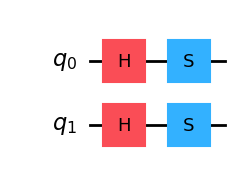

Statevector: Statevector([ 0.5+0.j ,  0. +0.5j,  0. +0.5j, -0.5+0.j ],
            dims=(2, 2))
Q-Sphere:


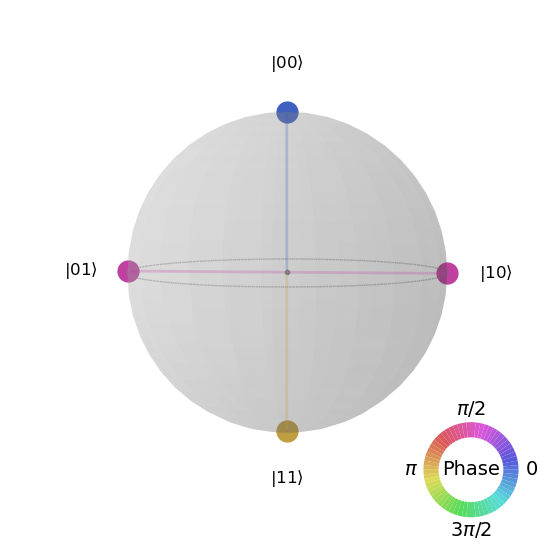

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere

# Create a 2-qubit circuit
qc1 = QuantumCircuit(2)

# Apply H gate to both qubits to create superposition
qc1.h(0)
qc1.h(1)

# Apply S gate (90 degree phase shift) to both qubits
qc1.s(0)
qc1.s(1)

print('Circuit:')
display(qc1.draw(output='mpl'))

# Compute statevector and visualize on Q-sphere
state1 = Statevector.from_instruction(qc1)
print('Statevector:', state1)

print('Q-Sphere:')
plot_state_qsphere(state1)

---
## Task 2: Write a Circuit in OpenQASM — Import and Run in Qiskit

- OpenQASM: A text-based language for describing quantum circuits
- `QuantumCircuit.from_qasm_str()`: Converts a QASM string into a Qiskit circuit
- `AerSimulator`: Runs the circuit on a local quantum simulator

Circuit imported from OpenQASM:


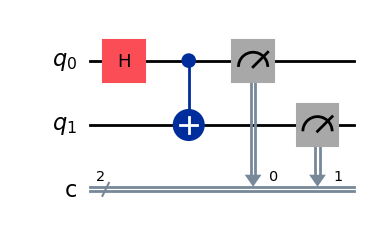

Measurement results: {'00': 504, '11': 520}


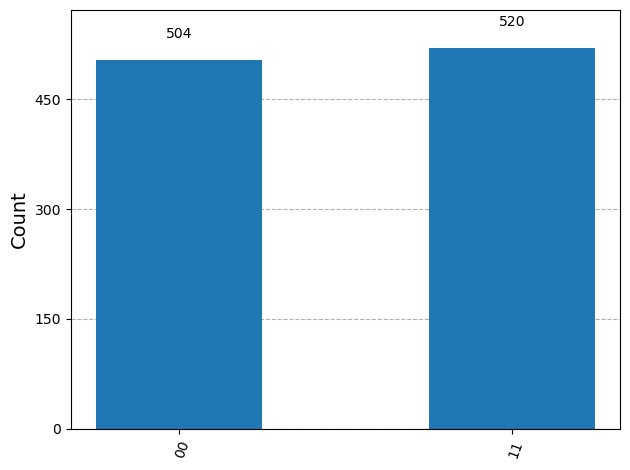

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Define a Bell state circuit in OpenQASM 2.0 format
qasm_string = """
OPENQASM 2.0;
include \"qelib1.inc\";

qreg q[2];
creg c[2];

h q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

# Import the QASM string as a Qiskit circuit
qc2 = QuantumCircuit.from_qasm_str(qasm_string)

print('Circuit imported from OpenQASM:')
display(qc2.draw(output='mpl'))

# Run on the Aer simulator
simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts()

print('Measurement results:', counts)
plot_histogram(counts)

---
## Task 3: Density Matrix — Diagonal and Off-Diagonal Elements

- **Density matrix**: A matrix representation of a quantum state
- **Diagonal elements**: Probability of measuring each basis state (real, sum to 1)
- **Off-diagonal elements**: Quantum coherence — non-zero means superposition exists
- Using a **2-qubit** H+H circuit so the 4x4 matrix (00, 01, 10, 11) is clearly visible in 3D

Circuit:


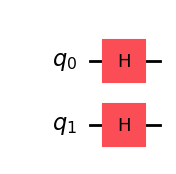


Full Density Matrix (Real part):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

Diagonal Elements (measurement probabilities):
  |00> : 0.250
  |01> : 0.250
  |10> : 0.250
  |11> : 0.250

Off-Diagonal Elements (coherence terms):
[[0.   0.25 0.25 0.25]
 [0.25 0.   0.25 0.25]
 [0.25 0.25 0.   0.25]
 [0.25 0.25 0.25 0.  ]]
  -> Non-zero values confirm the qubits are in superposition


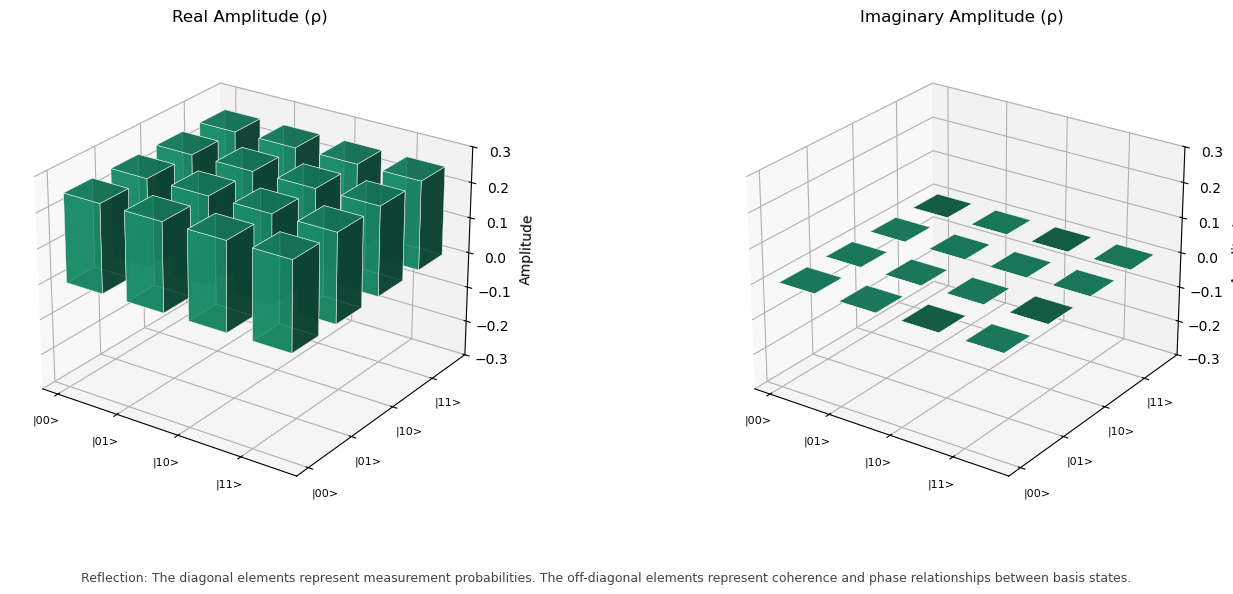

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix

# 2-qubit superposition circuit
qc3 = QuantumCircuit(2)
qc3.h(0)
qc3.h(1)

print('Circuit:')
display(qc3.draw(output='mpl'))

# Compute density matrix
dm = DensityMatrix.from_instruction(qc3)
matrix = dm.data

print('\nFull Density Matrix (Real part):')
print(np.round(matrix.real, 3))

# Diagonal elements
diagonal = np.diag(matrix).real
print('\nDiagonal Elements (measurement probabilities):')
labels = ['|00>', '|01>', '|10>', '|11>']
for lbl, val in zip(labels, diagonal):
    print(f'  {lbl} : {val:.3f}')

# Off-diagonal elements
off_diag = matrix.copy()
np.fill_diagonal(off_diag, 0)
print('\nOff-Diagonal Elements (coherence terms):')
print(np.round(off_diag.real, 3))
print('  -> Non-zero values confirm the qubits are in superposition')

# ---- 3D Bar Chart Visualization ----
n = 4
xpos, ypos = np.meshgrid(range(n), range(n))
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros(n * n)
dz_real = matrix.real.flatten()
dz_imag = matrix.imag.flatten()

# Color: teal for positive, coral for negative
def bar_colors(values):
    return ['#1D9E75' if v >= 0 else '#D85A30' for v in values]

tick_labels = ['|00>', '|01>', '|10>', '|11>']

fig = plt.figure(figsize=(14, 6))

# Real part
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz_real,
          color=bar_colors(dz_real), alpha=0.85, edgecolor='white', linewidth=0.4)
ax1.set_title('Real Amplitude (\u03c1)', fontsize=12, pad=10)
ax1.set_xticks(range(n))
ax1.set_xticklabels(tick_labels, fontsize=8)
ax1.set_yticks(range(n))
ax1.set_yticklabels(tick_labels, fontsize=8)
ax1.set_zlabel('Amplitude')
ax1.set_zlim(-0.3, 0.3)
ax1.view_init(elev=25, azim=-55)

# Imaginary part
ax2 = fig.add_subplot(122, projection='3d')
ax2.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz_imag,
          color=bar_colors(dz_imag), alpha=0.85, edgecolor='white', linewidth=0.4)
ax2.set_title('Imaginary Amplitude (\u03c1)', fontsize=12, pad=10)
ax2.set_xticks(range(n))
ax2.set_xticklabels(tick_labels, fontsize=8)
ax2.set_yticks(range(n))
ax2.set_yticklabels(tick_labels, fontsize=8)
ax2.set_zlabel('Amplitude')
ax2.set_zlim(-0.3, 0.3)
ax2.view_init(elev=25, azim=-55)

fig.text(0.5, 0.01,
         'Reflection: The diagonal elements represent measurement probabilities. '
         'The off-diagonal elements represent coherence and phase relationships between basis states.',
         ha='center', fontsize=9, color='#444441')

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.92, wspace=0.3)
plt.show()

---
## Task 4: Draw a Random Circuit (No dump method)

- `random_circuit()`: Qiskit's built-in random circuit generator
- `draw(output='mpl')`: Renders the circuit as a diagram — no dump method used
- `plot_bloch_multivector`: Shows each qubit's state on its own Bloch sphere

Random Circuit:


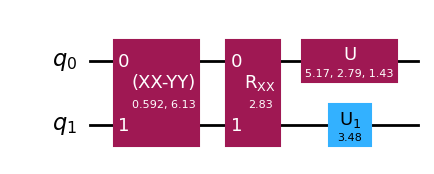

Statevector: Statevector([ 0.11560137-0.03730751j,  0.05937863-0.04682227j,
              0.51333473+0.10030925j, -0.82913175+0.13598669j],
            dims=(2, 2))
Bloch sphere for each qubit:


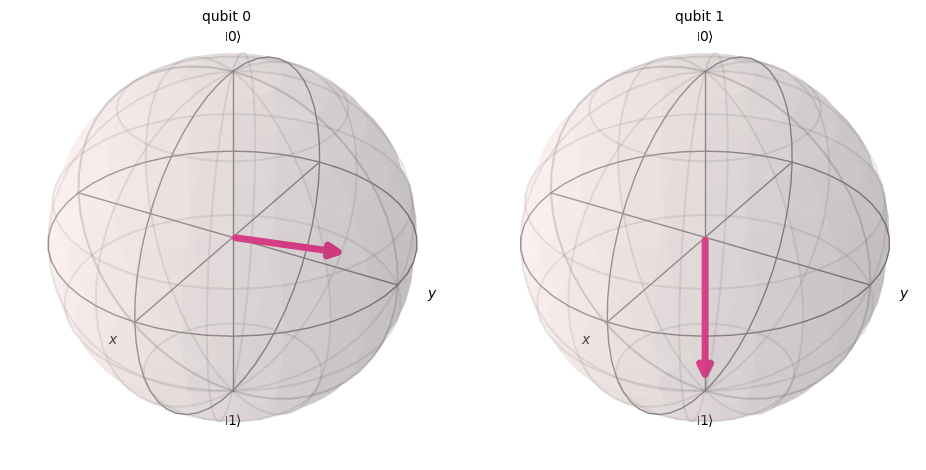

In [5]:
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Generate a random 2-qubit circuit with depth 3
# seed=42 ensures the same circuit is produced every run
qc4 = random_circuit(num_qubits=2, depth=3, seed=42)

print('Random Circuit:')
display(qc4.draw(output='mpl'))  # draw() only — no dump method

# Remove final measurements to extract statevector
qc4_no_meas = qc4.remove_final_measurements(inplace=False)

state4 = Statevector.from_instruction(qc4_no_meas)
print('Statevector:', state4)

print('Bloch sphere for each qubit:')
plot_bloch_multivector(state4)